# Лабораторная работа №2 — эксперименты (2.2–2.6 и Трек 4)

Графики отображаются сохраняются в `report/figures/` в формате *.png.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.datasets import load_svmlight_file
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

FIGURES = ROOT / "report" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

from optimization import (
    gradient_descent,
    newton,
    linear_conjugate_gradients,
    nonlinear_conjugate_gradients,
    hessian_free_newton,
    lbfgs,
    cautious_lbfgs,
)
from oracles import (
    BealeOracle,
    QuadraticOracle,
    LogisticL2Oracle,
    PoissonL2Oracle,
    hess_vec_finite_diff,
)

RNG = np.random.default_rng(42)


## 0. Датасеты

По ТЗ базовые эксперименты выполняются на **том же пакете оракулов и датасетов, что и в Лабораторной работе №1**.


In [2]:
DATASETS = {
    "classification": [
        ROOT / "data" / "phishing.txt",
        ROOT / "data" / "real-sim" / "real-sim",
    ],
    "regression": [
        ROOT / "data" / "cadata.txt",
        ROOT / "data" / "space_ga.txt",
    ],
}

for task, paths in DATASETS.items():
    print(task)
    for path in paths:
        print("  ", path, "OK" if path.exists() else "MISSING")


classification
   c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\data\phishing.txt OK
   c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\data\real-sim\real-sim OK
regression
   c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\data\cadata.txt OK
   c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\data\space_ga.txt OK


In [3]:
def require_file(path: Path) -> Path:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Нет файла данных: {p}")
    return p


def load_libsvm_dataset(path):
    X, y = load_svmlight_file(str(path))
    return X.tocsr(), np.asarray(y, dtype=float)


def make_logistic_oracle(X, y_raw, regcoef=None):
    y = np.where(y_raw > 0, 1.0, -1.0)
    if regcoef is None:
        regcoef = 1.0 / X.shape[0]
    return LogisticL2Oracle(X, y, regcoef), y


def make_poisson_oracle(X, y_raw, regcoef=None):
    y = y_raw.astype(float)
    y = y - y.min() + 1e-3
    if regcoef is None:
        regcoef = 1.0 / X.shape[0]
    return PoissonL2Oracle(X, y, regcoef), y


def get_dataset_oracle(path, task):
    X, y = load_libsvm_dataset(path)
    if task == "classification":
        oracle, y = make_logistic_oracle(X, y)
    else:
        oracle, y = make_poisson_oracle(X, y)
    return X, y, oracle


def relative_grad_sq(history):
    g = np.asarray(history["grad_norm"], dtype=float)
    g0 = max(float(g[0]), 1e-30)
    return (g / g0) ** 2


def rel_grad_tol_squared(eps_linear=1e-6):
    """В optimization.py: ||g||^2 <= tol * ||g0||^2.
    Чтобы выполнялось ||g|| <= eps * ||g0||, нужно tol = eps^2."""
    return float(eps_linear * eps_linear)


# Для п. 2.4–2.6: критерий ||g_k|| <= eps * ||g_0|| при eps = 1e-6
EPS_GRAD = 1e-6
TOLERANCE = EPS_GRAD ** 2
MAX_ITER = 3000

METHOD_LABELS = {
    "gd": "GD",
    "ncg": "NCG (PR)",
    "hfn": "HFN",
    "lbfgs": "L-BFGS (L=10)",
    "newton": "Ньютон",
}


def run_method(name, oracle, x0, trace_micro=False):
    ls_wolfe = {"method": "Wolfe"}
    if name == "gd":
        return gradient_descent(
            oracle, x0, tolerance=TOLERANCE, max_iter=MAX_ITER,
            line_search_options=ls_wolfe, trace=True, display=False,
        )
    if name == "newton":
        return newton(
            oracle, x0, tolerance=TOLERANCE, max_iter=200,
            line_search_options=ls_wolfe, trace=True, display=False,
        )
    if name == "ncg":
        return nonlinear_conjugate_gradients(
            oracle, x0, tolerance=TOLERANCE, max_iter=MAX_ITER,
            line_search_options=ls_wolfe, trace=True, display=False,
        )
    if name == "hfn":
        return hessian_free_newton(
            oracle, x0, tolerance=TOLERANCE, max_iter=MAX_ITER,
            line_search_options={**ls_wolfe, "alpha_0": 1.0}, trace=True, display=False,
        )
    if name == "lbfgs":
        return lbfgs(
            oracle, x0, tolerance=TOLERANCE, max_iter=MAX_ITER, memory_size=10,
            line_search_options=ls_wolfe, trace=True, display=False,
        )
    raise ValueError(name)


## 1. Проверка `hess_vec` через конечные разности


In [4]:
m, n = 20, 7
X_dense = RNG.normal(size=(m, n))
y_clf = RNG.choice([-1.0, 1.0], size=m)
y_reg = np.abs(RNG.normal(size=m)) + 0.1

matrix_variants = {
    "dense": X_dense,
    "sparse": csr_matrix(X_dense),
}

print("| Matrix Type | Oracle | Trial | Error |")
print("|---|---|---:|---:|")

for matrix_type, X_mat in matrix_variants.items():
    for trial in range(1, 6):
        x = RNG.normal(size=n)
        v = RNG.normal(size=n)

        log_oracle = LogisticL2Oracle(X_mat, y_clf, regcoef=1.0 / m)
        poi_oracle = PoissonL2Oracle(X_mat, y_reg, regcoef=1.0 / m)

        for oracle_name, oracle in (("LogisticL2", log_oracle), ("PoissonL2", poi_oracle)):
            hv = oracle.hess_vec(x, v)
            hv_fd = hess_vec_finite_diff(oracle.func, x, v)
            err = float(np.linalg.norm(hv - hv_fd))
            print(f"| {matrix_type} | {oracle_name} | {trial} | {err:.6e} |")


| Matrix Type | Oracle | Trial | Error |
|---|---|---:|---:|
| dense | LogisticL2 | 1 | 9.207629e-06 |
| dense | PoissonL2 | 1 | 2.315458e-04 |
| dense | LogisticL2 | 2 | 1.941035e-05 |
| dense | PoissonL2 | 2 | 1.536692e-04 |
| dense | LogisticL2 | 3 | 1.979152e-05 |
| dense | PoissonL2 | 3 | 1.905209e-04 |
| dense | LogisticL2 | 4 | 8.455659e-06 |
| dense | PoissonL2 | 4 | 7.033042e-05 |
| dense | LogisticL2 | 5 | 3.606762e-05 |
| dense | PoissonL2 | 5 | 1.364603e-03 |
| sparse | LogisticL2 | 1 | 3.354495e-05 |
| sparse | PoissonL2 | 1 | 6.372739e-05 |
| sparse | LogisticL2 | 2 | 9.719337e-06 |
| sparse | PoissonL2 | 2 | 1.302367e-04 |
| sparse | LogisticL2 | 3 | 7.618943e-06 |
| sparse | PoissonL2 | 3 | 4.909624e-02 |
| sparse | LogisticL2 | 4 | 1.376027e-05 |
| sparse | PoissonL2 | 4 | 3.518399e-05 |
| sparse | LogisticL2 | 5 | 1.930187e-05 |
| sparse | PoissonL2 | 5 | 1.508627e-03 |


## 2. Эксперимент 2.2 — линейный CG против GD на квадратичных задачах


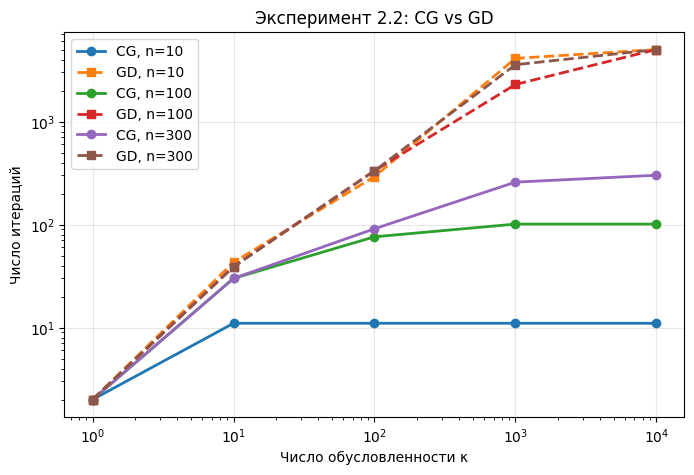

In [5]:
def build_diagonal_quadratic(n, kappa):
    diag = np.geomspace(1.0, kappa, n)
    A = np.diag(diag)
    b = np.ones(n)
    return A, b


def quadratic_gd(A, b, x0, tol=1e-8, max_iter=20000):
    oracle = QuadraticOracle(A, b)
    return gradient_descent(
        oracle, x0, tolerance=tol, max_iter=max_iter,
        line_search_options={"method": "Wolfe"}, trace=True
    )


def quadratic_cg(A, b, x0, tol=1e-8, max_iter=None):
    return linear_conjugate_gradients(lambda v: A @ v, b, x0, tolerance=tol, max_iter=max_iter, trace=True)


kappas = [1, 10, 1e2, 1e3, 1e4]
dims = [10, 100, 300]

results_cg = {n: [] for n in dims}
results_gd = {n: [] for n in dims}

for n in dims:
    for kappa in kappas:
        A, b = build_diagonal_quadratic(n, kappa)
        x0 = np.zeros(n)
        _, _, hist_cg = quadratic_cg(A, b, x0)
        _, _, hist_gd = quadratic_gd(A, b, x0, max_iter=5000)
        results_cg[n].append(len(hist_cg["residual_norm"]))
        results_gd[n].append(len(hist_gd["grad_norm"]))

fig = plt.figure()
for n in dims:
    plt.plot(kappas, results_cg[n], marker="o", linewidth=2, label=f"CG, n={n}")
    plt.plot(kappas, results_gd[n], marker="s", linewidth=2, linestyle="--", label=f"GD, n={n}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Число обусловленности κ")
plt.ylabel("Число итераций")
plt.title("Эксперимент 2.2: CG vs GD")
plt.legend()
fig.savefig(FIGURES / "exp22_cg_vs_gd.png", bbox_inches="tight")
plt.show()


## 3. Эксперимент 2.3 — влияние размера истории в L-BFGS


Теоретическая справка: Память метода ~ 2Ln чисел. Сложность вычисления направления (двухцикловая рекурсия) — O(Ln) на итерацию.


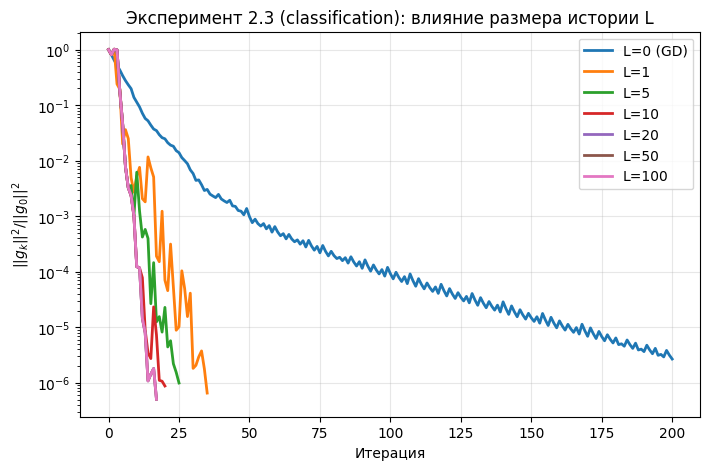

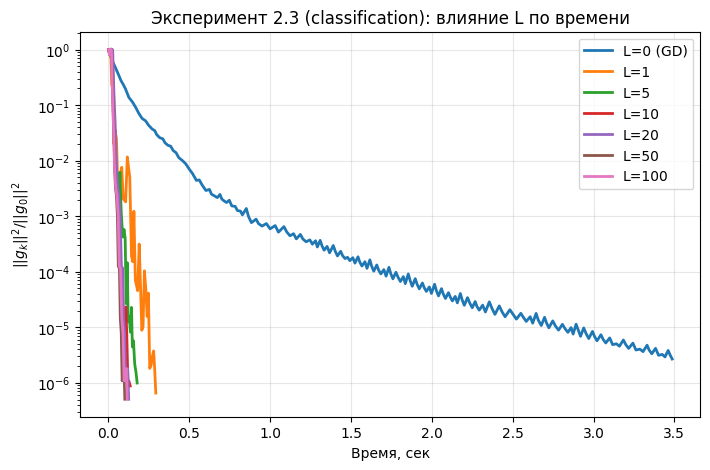

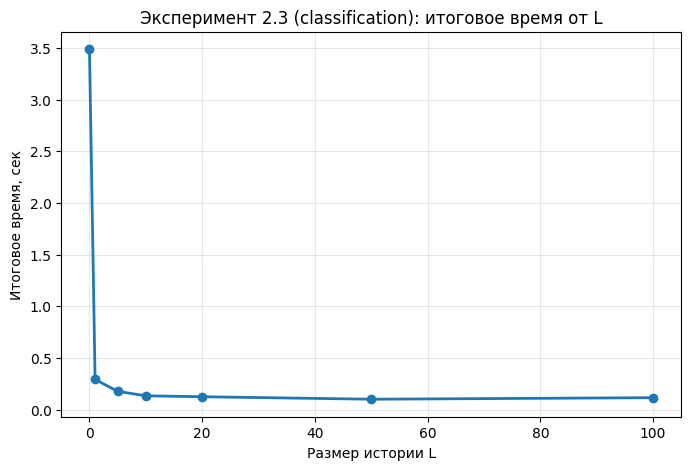


[2.3] Сводка по задаче: classification
| L | iterations | time | final rel grad |
|---:|---:|---:|---:|
| 0 | 200 | 3.486555 | 2.679916e-06 |
| 1 | 35 | 0.293081 | 6.531834e-07 |
| 5 | 25 | 0.177948 | 9.918553e-07 |
| 10 | 20 | 0.134737 | 8.759874e-07 |
| 20 | 17 | 0.125572 | 5.059502e-07 |
| 50 | 17 | 0.101598 | 5.059502e-07 |
| 100 | 17 | 0.116461 | 5.059502e-07 |


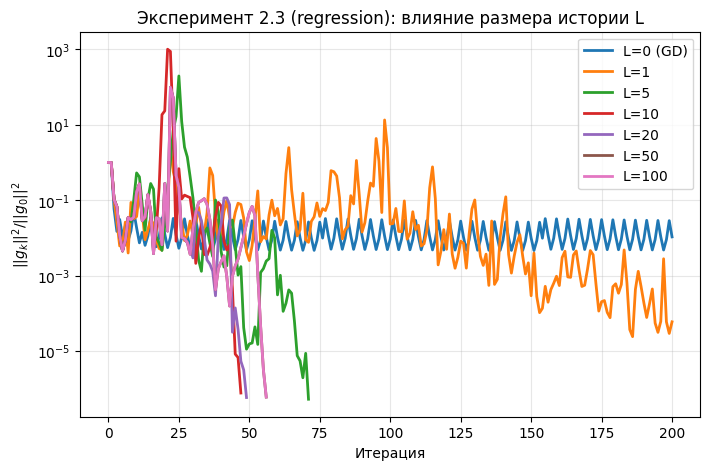

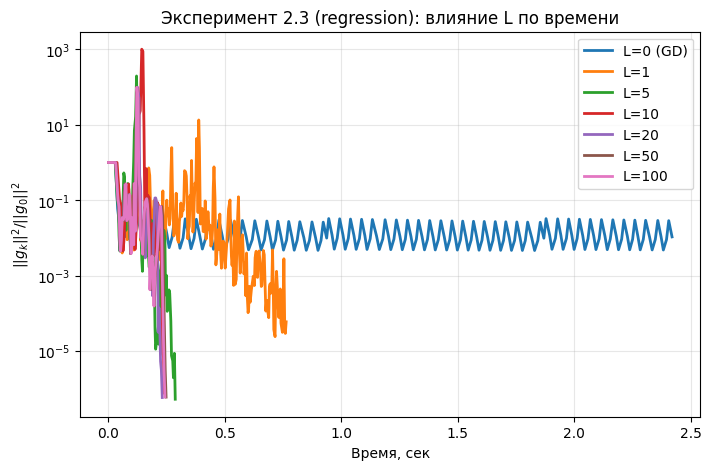

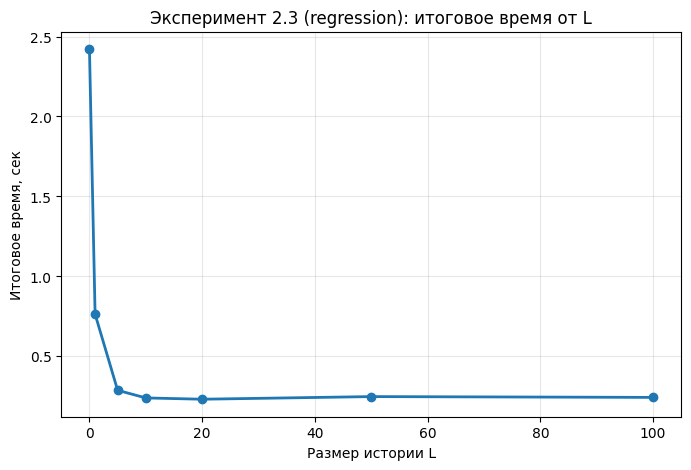


[2.3] Сводка по задаче: regression
| L | iterations | time | final rel grad |
|---:|---:|---:|---:|
| 0 | 200 | 2.420565 | 1.061185e-02 |
| 1 | 200 | 0.763909 | 5.917132e-05 |
| 5 | 71 | 0.287749 | 5.238313e-07 |
| 10 | 47 | 0.240076 | 7.653048e-07 |
| 20 | 49 | 0.231979 | 5.808728e-07 |
| 50 | 56 | 0.248421 | 5.970100e-07 |
| 100 | 56 | 0.243428 | 6.019412e-07 |


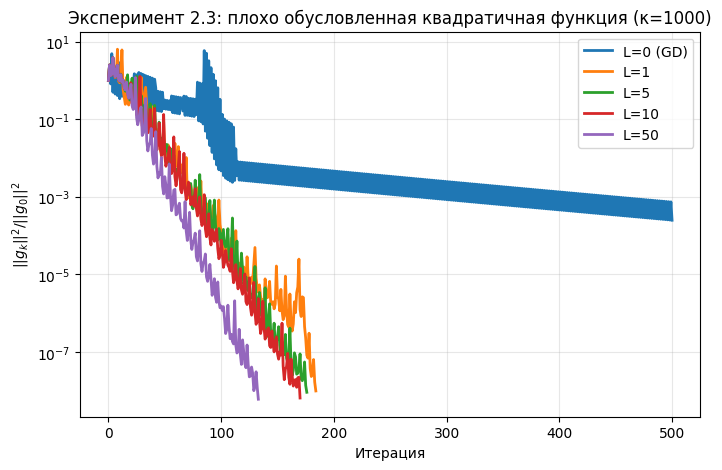

In [6]:
memory_sizes = [0, 1, 5, 10, 20, 50, 100]

print("Теоретическая справка: Память метода ~ 2Ln чисел. Сложность вычисления направления (двухцикловая рекурсия) — O(Ln) на итерацию.")

for task in ["classification", "regression"]:
    path = DATASETS[task][0]
    if not path.exists():
        print("Файл не найден:", path)
        continue

    X, y, oracle = get_dataset_oracle(path, task)
    x0 = np.zeros(X.shape[1])
    histories = {}

    for L in memory_sizes:
        if L == 0:
            _, msg, hist = gradient_descent(
                oracle,
                x0,
                tolerance=1e-6,
                max_iter=200,
                line_search_options={"method": "Wolfe"},
                trace=True,
            )
            histories[L] = hist
        else:
            _, msg, hist = lbfgs(
                oracle,
                x0,
                tolerance=1e-6,
                max_iter=200,
                memory_size=L,
                line_search_options={"method": "Wolfe"},
                trace=True,
            )
            histories[L] = hist

    fig = plt.figure()
    for L in memory_sizes:
        hist = histories[L]
        label = "L=0 (GD)" if L == 0 else f"L={L}"
        plt.plot(np.arange(len(hist["grad_norm"])), relative_grad_sq(hist), linewidth=2, label=label)
    plt.yscale("log")
    plt.xlabel("Итерация")
    plt.ylabel(r"$||g_k||^2 / ||g_0||^2$")
    plt.title(f"Эксперимент 2.3 ({task}): влияние размера истории L")
    plt.legend()
    fig.savefig(FIGURES / f"exp23_lbfgs_memory_vs_iter_{task}.png", bbox_inches="tight")
    plt.show()

    fig = plt.figure()
    for L in memory_sizes:
        hist = histories[L]
        label = "L=0 (GD)" if L == 0 else f"L={L}"
        plt.plot(hist["time"], relative_grad_sq(hist), linewidth=2, label=label)
    plt.yscale("log")
    plt.xlabel("Время, сек")
    plt.ylabel(r"$||g_k||^2 / ||g_0||^2$")
    plt.title(f"Эксперимент 2.3 ({task}): влияние L по времени")
    plt.legend()
    fig.savefig(FIGURES / f"exp23_lbfgs_memory_vs_time_{task}.png", bbox_inches="tight")
    plt.show()

    final_times = [histories[L]["time"][-1] for L in memory_sizes]
    fig = plt.figure()
    plt.plot(memory_sizes, final_times, marker="o", linewidth=2)
    plt.xlabel("Размер истории L")
    plt.ylabel("Итоговое время, сек")
    plt.title(f"Эксперимент 2.3 ({task}): итоговое время от L")
    fig.savefig(FIGURES / f"exp23_lbfgs_final_time_vs_memory_{task}.png", bbox_inches="tight")
    plt.show()

    print(f"\n[2.3] Сводка по задаче: {task}")
    print("| L | iterations | time | final rel grad |")
    print("|---:|---:|---:|---:|")
    for L in memory_sizes:
        hist = histories[L]
        iters = max(len(hist["func"]) - 1, 0)
        t_final = float(np.asarray(hist["time"], dtype=float)[-1])
        rel_final = float(relative_grad_sq(hist)[-1])
        print(f"| {L} | {iters} | {t_final:.6f} | {rel_final:.6e} |")

# Иллюстрация на плохо обусловленной квадратичной функции
A, b = build_diagonal_quadratic(n=100, kappa=1000)
quad_oracle = QuadraticOracle(A, b)
x0_quad = np.zeros(100)
quad_histories = {}

_, _, hist_gd_quad = gradient_descent(
    quad_oracle,
    x0_quad.copy(),
    tolerance=1e-8,
    max_iter=500,
    line_search_options={"method": "Wolfe"},
    trace=True,
)
quad_histories[0] = hist_gd_quad

for L in [1, 5, 10, 50]:
    _, _, hist_lbfgs_quad = lbfgs(
        quad_oracle,
        x0_quad.copy(),
        tolerance=1e-8,
        max_iter=500,
        memory_size=L,
        line_search_options={"method": "Wolfe"},
        trace=True,
    )
    quad_histories[L] = hist_lbfgs_quad

fig = plt.figure()
for L in [0, 1, 5, 10, 50]:
    hist = quad_histories[L]
    label = "L=0 (GD)" if L == 0 else f"L={L}"
    plt.plot(np.arange(len(hist["grad_norm"])), relative_grad_sq(hist), linewidth=2, label=label)
plt.yscale("log")
plt.xlabel("Итерация")
plt.ylabel(r"$||g_k||^2 / ||g_0||^2$")
plt.title("Эксперимент 2.3: плохо обусловленная квадратичная функция (κ=1000)")
plt.legend()
fig.savefig(FIGURES / "exp23_lbfgs_quadratic_kappa1000.png", bbox_inches="tight")
plt.show()


## 4. Эксперимент 2.4 — сравнение методов (phishing, cadata, real-sim)


[2.4] phishing / gd: success, итераций (записей в истории) = 1018
[2.4] phishing / ncg: success, итераций (записей в истории) = 808
[2.4] phishing / hfn: success, итераций (записей в истории) = 7
[2.4] phishing / lbfgs: success, итераций (записей в истории) = 160
[2.4] phishing / newton: success, итераций (записей в истории) = 7
[2.4] cadata / gd: iterations_exceeded, итераций (записей в истории) = 3001
[2.4] cadata / ncg: iterations_exceeded, итераций (записей в истории) = 3001
[2.4] cadata / hfn: success, итераций (записей в истории) = 1568
[2.4] cadata / lbfgs: success, итераций (записей в истории) = 154
[2.4] cadata / newton: success, итераций (записей в истории) = 9
[2.4] real-sim: Полный метод Ньютона пропущен из-за огромной размерности признаков (n >> 1000)


c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\src\utils.py:106: LineSearchWarning: The line search algorithm did not converge
  alpha = scalar_search_wolfe2(


[2.4] real-sim / gd: success, итераций (записей в истории) = 574
[2.4] real-sim / ncg: success, итераций (записей в истории) = 574
[2.4] real-sim / hfn: success, итераций (записей в истории) = 8
[2.4] real-sim / lbfgs: success, итераций (записей в истории) = 1303


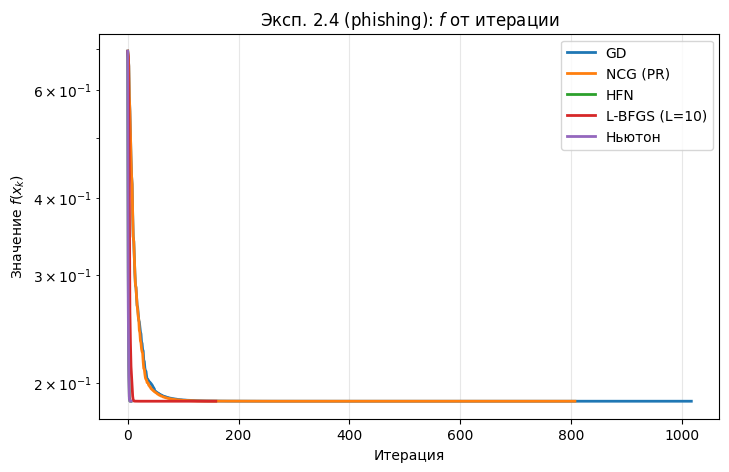

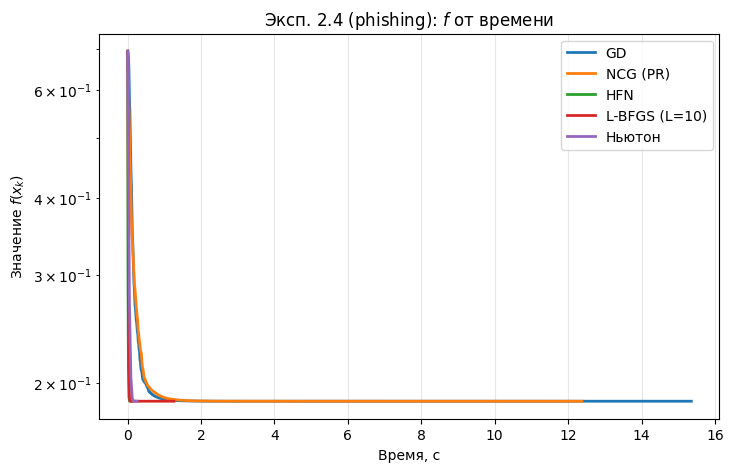

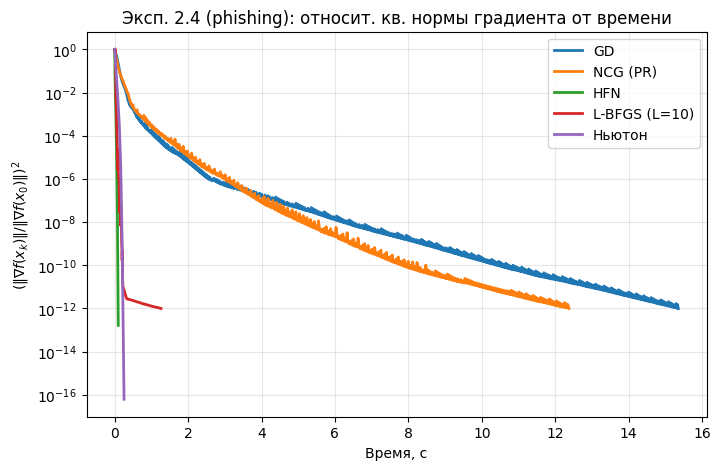

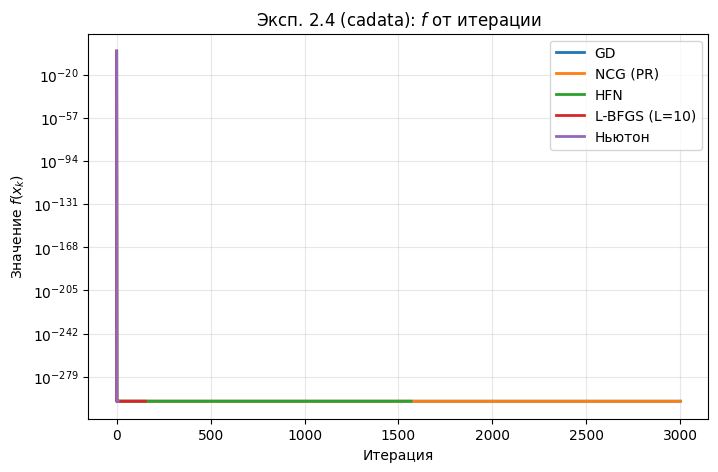

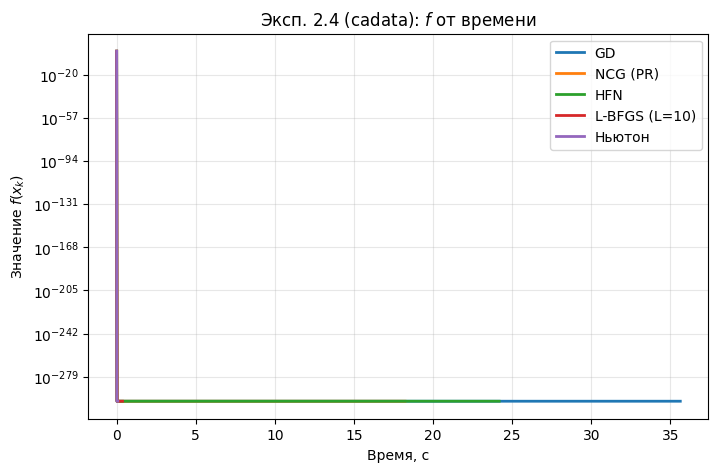

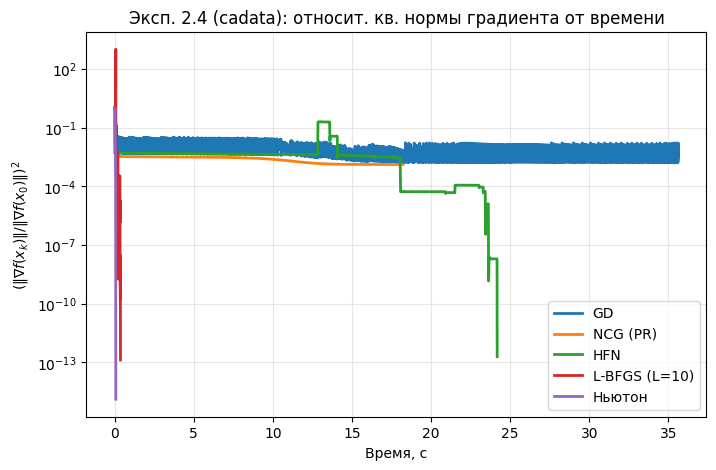

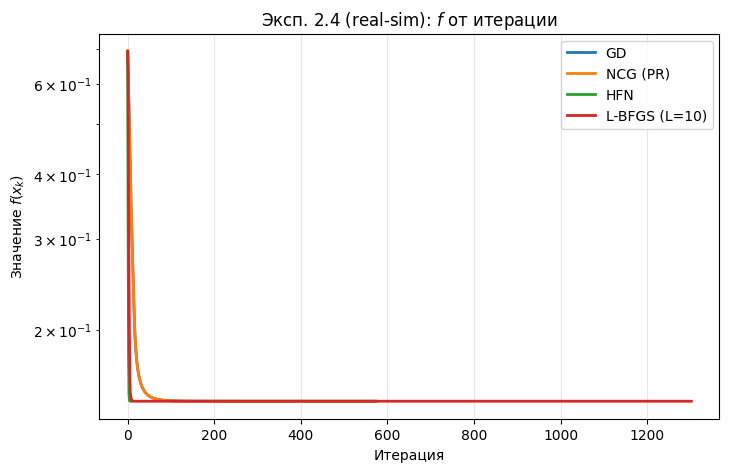

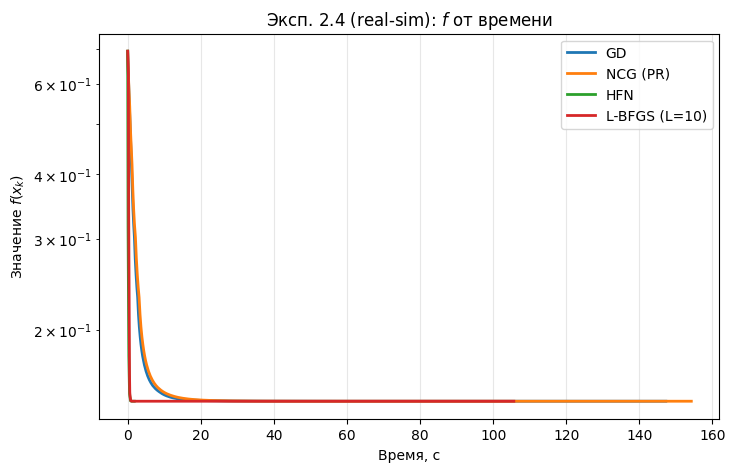

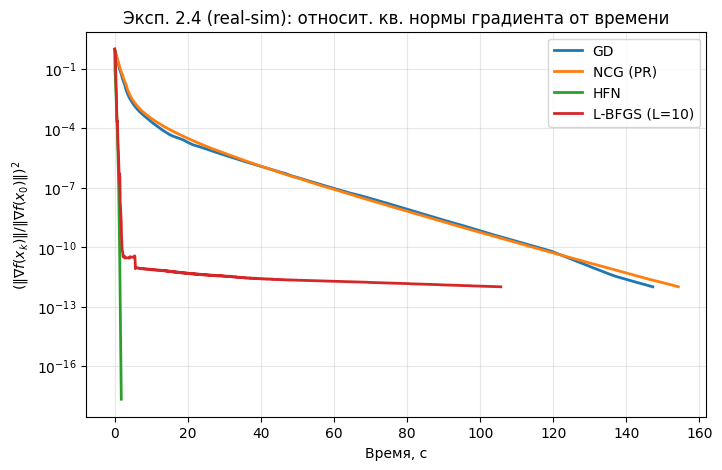

2.4: PNG сохранены в c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\report\figures
Проверка графиков f(x_k) от итерации:
 - c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\report\figures\exp24_func_vs_iter_phishing.png
 - c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\report\figures\exp24_func_vs_iter_cadata.png
 - c:\Users\Kolya\Desktop\AI360-edc\МетОпты\laba2\MetOpt_lab2_team20\report\figures\exp24_func_vs_iter_real-sim.png

| Method | Dataset | Status | Iterations | Time | Final Criterion |
|---|---|---:|---:|---:|---:|
| GD | phishing | success | 1017 | 15.356451 | 9.860353e-13 |
| NCG (PR) | phishing | success | 807 | 12.377264 | 9.985279e-13 |
| HFN | phishing | success | 6 | 0.096513 | 1.651296e-13 |
| L-BFGS (L=10) | phishing | success | 159 | 1.261580 | 9.936211e-13 |
| Ньютон | phishing | success | 6 | 0.254475 | 6.230173e-17 |
| GD | cadata | exceeded | 3000 | 35.624215 | 2.882178e-03 |
| NCG (PR) | cadata | exceeded | 

In [7]:
paths_24 = {
    "phishing": (require_file(ROOT / "data" / "phishing.txt"), "classification"),
    "cadata": (require_file(ROOT / "data" / "cadata.txt"), "regression"),
    "real-sim": (require_file(ROOT / "data" / "real-sim" / "real-sim"), "classification"),
}

histories_24 = {}
micro_sources = {}

for slug, (path, task) in paths_24.items():
    X, y_raw = load_libsvm_dataset(path)
    n = X.shape[1]
    x0 = np.zeros(n, dtype=float)

    methods = ["gd", "ncg", "hfn", "lbfgs"]
    if n < 1000:
        methods = methods + ["newton"]
    elif slug == "real-sim" and n > 1000:
        print(
            "[2.4] real-sim: Полный метод Ньютона пропущен из-за огромной размерности признаков (n >> 1000)"
        )

    histories_24[slug] = {}
    for m in methods:
        if task == "classification":
            oracle, _ = make_logistic_oracle(X, y_raw)
        else:
            oracle, _ = make_poisson_oracle(X, y_raw)
        xf, msg, hist = run_method(m, oracle, x0)
        histories_24[slug][m] = hist
        print(f"[2.4] {slug} / {m}: {msg}, итераций (записей в истории) = {len(hist['func'])}")

    for m in ("ncg", "hfn", "lbfgs"):
        micro_sources.setdefault(m, []).append(histories_24[slug][m])

colors = plt.cm.tab10(np.linspace(0, 0.9, 10))

for slug in paths_24:
    hists = histories_24[slug]
    fig, ax = plt.subplots()
    for mi, (m, hist) in enumerate(hists.items()):
        it = np.arange(len(hist["func"]))
        fvals = np.clip(np.asarray(hist["func"], dtype=float), 1e-300, None)
        ax.plot(it, fvals, lw=2, label=METHOD_LABELS.get(m, m), color=colors[mi % 10])
    ax.set_yscale("log")
    ax.set_xlabel("Итерация")
    ax.set_ylabel(r"Значение $f(x_k)$")
    ax.set_title(f"Эксп. 2.4 ({slug}): $f$ от итерации")
    ax.legend()
    fig.savefig(FIGURES / f"exp24_func_vs_iter_{slug}.png", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots()
    for mi, (m, hist) in enumerate(hists.items()):
        t = np.asarray(hist["time"], dtype=float)
        fvals = np.clip(np.asarray(hist["func"], dtype=float), 1e-300, None)
        ax.plot(t, fvals, lw=2, label=METHOD_LABELS.get(m, m), color=colors[mi % 10])
    ax.set_yscale("log")
    ax.set_xlabel("Время, с")
    ax.set_ylabel(r"Значение $f(x_k)$")
    ax.set_title(f"Эксп. 2.4 ({slug}): $f$ от времени")
    ax.legend()
    fig.savefig(FIGURES / f"exp24_func_vs_time_{slug}.png", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots()
    for mi, (m, hist) in enumerate(hists.items()):
        t = np.asarray(hist["time"], dtype=float)
        rgsq = np.clip(relative_grad_sq(hist), 1e-300, None)
        ax.plot(t, rgsq, lw=2, label=METHOD_LABELS.get(m, m), color=colors[mi % 10])
    ax.set_yscale("log")
    ax.set_xlabel("Время, с")
    ax.set_ylabel(r"$(\Vert\nabla f(x_k)\Vert / \Vert\nabla f(x_0)\Vert)^2$")
    ax.set_title(f"Эксп. 2.4 ({slug}): относит. кв. нормы градиента от времени")
    ax.legend()
    fig.savefig(FIGURES / f"exp24_gradnorm_vs_time_{slug}.png", bbox_inches="tight")
    plt.show()

print("2.4: PNG сохранены в", FIGURES)
print("Проверка графиков f(x_k) от итерации:")
print(" -", FIGURES / "exp24_func_vs_iter_phishing.png")
print(" -", FIGURES / "exp24_func_vs_iter_cadata.png")
print(" -", FIGURES / "exp24_func_vs_iter_real-sim.png")

print("\n| Method | Dataset | Status | Iterations | Time | Final Criterion |")
print("|---|---|---:|---:|---:|---:|")
for slug in paths_24:
    for m, hist in histories_24[slug].items():
        final_rel = float(relative_grad_sq(hist)[-1])
        status = "success" if final_rel <= TOLERANCE else "exceeded"
        iters = max(len(hist["func"]) - 1, 0)
        t_final = float(np.asarray(hist["time"], dtype=float)[-1])
        method_name = METHOD_LABELS.get(m, m)
        print(f"| {method_name} | {slug} | {status} | {iters} | {t_final:.6f} | {final_rel:.6e} |")


## 5. Эксперимент 2.5 — микропрофилирование (NCG, HFN, L-BFGS)


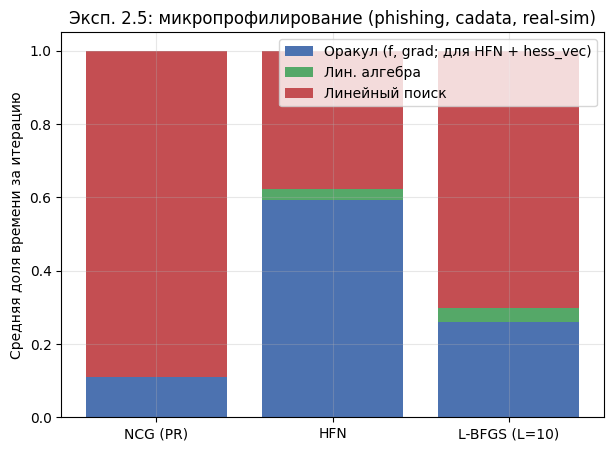


Эксп. 2.5: табличная сводка долей времени
Метод           |   Oracle | Linear algebra | Line search
------------------------------------------------------------
NCG (PR)        |    0.109 |          0.001 |       0.890
HFN             |    0.592 |          0.031 |       0.377
L-BFGS (L=10)   |    0.261 |          0.037 |       0.702


In [8]:
def mean_time_fractions(histories):
    o_acc, l_acc, s_acc = [], [], []
    for h in histories:
        o = np.asarray(h.get("time_oracle", []), dtype=float)
        l_ = np.asarray(h.get("time_linalg", []), dtype=float)
        s = np.asarray(h.get("time_linesearch", []), dtype=float)
        if o.size <= 1:
            continue
        o, l_, s = o[1:], l_[1:], s[1:]
        tot = o + l_ + s
        mask = tot > 0
        if not np.any(mask):
            continue
        o_acc.append(np.mean(o[mask] / tot[mask]))
        l_acc.append(np.mean(l_[mask] / tot[mask]))
        s_acc.append(np.mean(s[mask] / tot[mask]))
    if not o_acc:
        return 0.33, 0.33, 0.34
    return float(np.mean(o_acc)), float(np.mean(l_acc)), float(np.mean(s_acc))


fracs = {}
for m in ("ncg", "hfn", "lbfgs"):
    fracs[m] = mean_time_fractions(micro_sources[m])

methods_order = ("ncg", "hfn", "lbfgs")
labels_ru = [METHOD_LABELS[m] for m in methods_order]
O = np.array([fracs[m][0] for m in methods_order])
L = np.array([fracs[m][1] for m in methods_order])
S = np.array([fracs[m][2] for m in methods_order])

xpos = np.arange(len(methods_order))
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(xpos, O, label="Оракул (f, grad; для HFN + hess_vec)", color="#4C72B0")
ax.bar(xpos, L, bottom=O, label="Лин. алгебра", color="#55A868")
ax.bar(xpos, S, bottom=O + L, label="Линейный поиск", color="#C44E52")
ax.set_xticks(xpos)
ax.set_xticklabels(labels_ru)
ax.set_ylabel("Средняя доля времени за итерацию")
ax.set_title("Эксп. 2.5: микропрофилирование (phishing, cadata, real-sim)")
ax.legend(loc="upper right")
fig.savefig(FIGURES / "exp25_microprofiling.png", bbox_inches="tight")
plt.show()

print("\nЭксп. 2.5: табличная сводка долей времени")
print(f"{'Метод':<15} | {'Oracle':>8} | {'Linear algebra':>14} | {'Line search':>11}")
print("-" * 60)
for m in methods_order:
    method_name = METHOD_LABELS.get(m, m)
    o, l_, s = fracs[m]
    print(f"{method_name:<15} | {o:>8.3f} | {l_:>14.3f} | {s:>11.3f}")


## 6. Эксперимент 2.6 — оптимизация vs качество на тесте


[2.6] clf λ = 0.1/m: success, best_metric=9.416554e-01, sat_iter=8, useless_time=80.93%
[2.6] clf λ = 1/m: success, best_metric=9.366802e-01, sat_iter=6, useless_time=77.02%
[2.6] clf λ = 10/m: success, best_metric=9.317051e-01, sat_iter=4, useless_time=75.34%


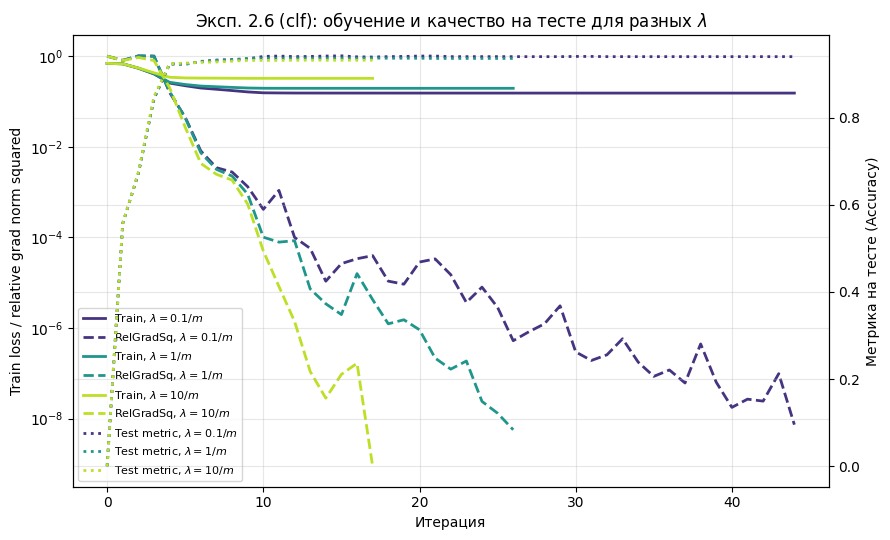


[2.6] Saturation summary (clf)
| λ | best test metric | saturation iter | useless time % |
|---:|---:|---:|---:|
| 0.1 | 9.416554e-01 | 8 | 80.93 |
| 1 | 9.366802e-01 | 6 | 77.02 |
| 10 | 9.317051e-01 | 4 | 75.34 |
[2.6] reg λ = 0.1/m: iterations_exceeded, best_metric=4.937354e+10, sat_iter=0, useless_time=99.99%
[2.6] reg λ = 1/m: iterations_exceeded, best_metric=4.937354e+10, sat_iter=0, useless_time=99.99%
[2.6] reg λ = 10/m: iterations_exceeded, best_metric=4.937354e+10, sat_iter=0, useless_time=99.99%


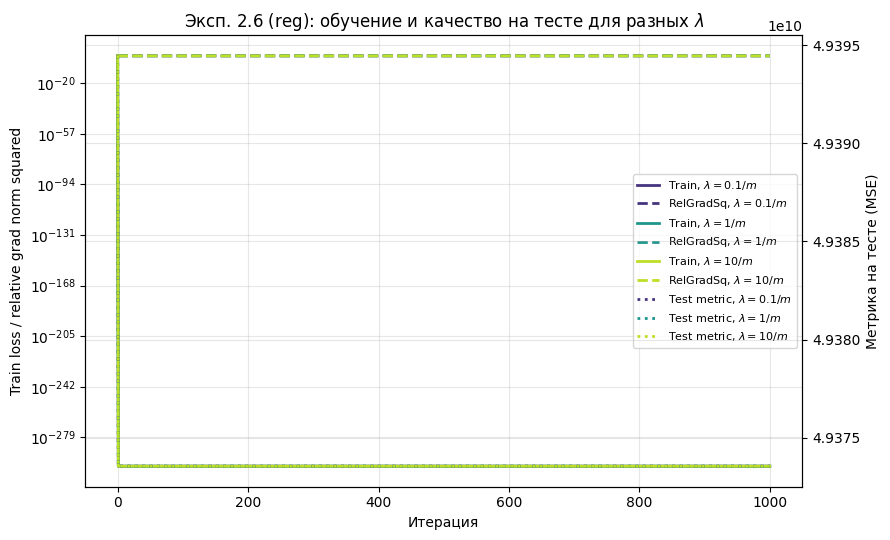


[2.6] Saturation summary (reg)
| λ | best test metric | saturation iter | useless time % |
|---:|---:|---:|---:|
| 0.1 | 4.937354e+10 | 0 | 99.99 |
| 1 | 4.937354e+10 | 0 | 99.99 |
| 10 | 4.937354e+10 | 0 | 99.99 |


In [9]:
def exp26_useless_time_stats(hist, task, metric_tol=1e-4):
    """Доля времени после первого достижения почти оптимальной тестовой метрики."""
    tm = np.asarray(hist["test_metric"], dtype=float)
    t = np.asarray(hist["time"], dtype=float)
    if tm.size == 0 or t.size == 0:
        return 0, 0.0, float(t[-1]) if t.size else 0.0, 0.0
    if task == "classification":
        best = float(np.max(tm))
        idx = np.where(tm >= best - metric_tol)[0]
    else:
        best = float(np.min(tm))
        idx = np.where(tm <= best + metric_tol)[0]
    i_best = int(idx[0]) if len(idx) else int(tm.size - 1)
    t_best = float(t[i_best])
    t_total = float(t[-1])
    useless_pct = 100.0 * (t_total - t_best) / t_total if t_total > 0 else 0.0
    return i_best, t_best, t_total, useless_pct


def exp26_run(path, task, slug, lambda_multipliers=None):
    if lambda_multipliers is None:
        lambda_multipliers = [0.1, 1.0, 10.0]

    X, y_raw = load_libsvm_dataset(path)
    strat = y_raw if task == "classification" else None
    X_tr, X_te, ytr, yte = train_test_split(
        X, y_raw, test_size=0.2, random_state=42, stratify=strat
    )
    m_tr = X_tr.shape[0]
    n = X_tr.shape[1]
    x0 = np.zeros(n, dtype=float)

    if task == "classification":
        y_tr_sign = np.where(ytr > 0, 1.0, -1.0)
        y_te_sign = np.where(yte > 0, 1.0, -1.0)
    else:
        ytr_f = ytr.astype(float)
        yte_f = yte.astype(float)
        base = ytr_f.min()
        y_tr_shift = ytr_f - base + 1e-3
        y_te_shift = yte_f - base + 1e-3

    histories = {}
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(lambda_multipliers)))
    sat_stats = {}

    for mult in lambda_multipliers:
        regcoef = float(mult) / m_tr
        if task == "classification":
            oracle = LogisticL2Oracle(X_tr, y_tr_sign, regcoef)

            def callback(x, kw, Xte=X_te, yte_=y_te_sign):
                pred = np.sign(Xte @ x)
                acc = accuracy_score(yte_, pred)
                return {"test_metric": float(acc)}
        else:
            oracle = PoissonL2Oracle(X_tr, y_tr_shift, regcoef)

            def callback(x, kw, Xte=X_te, yte_=y_te_shift):
                z = Xte @ x
                z = np.minimum(z, 50.0)
                pred = np.exp(z)
                mse = mean_squared_error(yte_, pred)
                return {"test_metric": float(mse)}

        xf, msg, hist = lbfgs(
            oracle,
            x0.copy(),
            tolerance=1e-8,
            max_iter=1000,
            memory_size=10,
            line_search_options={"method": "Wolfe"},
            trace=True,
            callback=callback,
            display=False,
        )
        histories[mult] = hist

        tm = np.asarray(hist["test_metric"], dtype=float)
        tt = np.asarray(hist["time"], dtype=float)
        if task == "classification":
            best = float(np.max(tm))
            sat_threshold = 0.99 * best
            sat_idx_candidates = np.where(tm >= sat_threshold)[0]
        else:
            best = float(np.min(tm))
            sat_threshold = best / 0.99
            sat_idx_candidates = np.where(tm <= sat_threshold)[0]

        sat_iter = int(sat_idx_candidates[0]) if len(sat_idx_candidates) else int(len(tm) - 1)
        t_sat = float(tt[sat_iter]) if len(tt) else 0.0
        t_total = float(tt[-1]) if len(tt) else 0.0
        useless_pct = 100.0 * (t_total - t_sat) / t_total if t_total > 0 else 0.0
        sat_stats[mult] = {
            "best_metric": best,
            "sat_iter": sat_iter,
            "useless_pct": useless_pct,
        }

        print(
            f"[2.6] {slug} λ = {mult:g}/m: {msg}, best_metric={best:.6e}, "
            f"sat_iter={sat_iter}, useless_time={useless_pct:.2f}%"
        )

    fig, ax1 = plt.subplots(figsize=(9, 5.5))
    ax2 = ax1.twinx()

    for ci, mult in enumerate(lambda_multipliers):
        hist = histories[mult]
        it = np.arange(len(hist["func"]))
        color = colors[ci]

        train_loss = np.clip(np.asarray(hist["func"], dtype=float), 1e-300, None)
        grad_rel_sq = np.clip(relative_grad_sq(hist), 1e-300, None)
        test_metric = np.asarray(hist["test_metric"], dtype=float)

        ax1.plot(it, train_loss, lw=2, color=color, linestyle="-", label=fr"Train, $\lambda={mult:g}/m$")
        ax1.plot(it, grad_rel_sq, lw=2, color=color, linestyle="--", label=fr"RelGradSq, $\lambda={mult:g}/m$")
        ax2.plot(it, test_metric, lw=2, color=color, linestyle=":", label=fr"Test metric, $\lambda={mult:g}/m$")

    ax1.set_yscale("log")
    ax1.set_xlabel("Итерация")
    ax1.set_ylabel("Train loss / relative grad norm squared")
    met = "Accuracy" if task == "classification" else "MSE"
    ax2.set_ylabel(f"Метрика на тесте ({met})")
    ax1.set_title(f"Эксп. 2.6 ({slug}): обучение и качество на тесте для разных $\\lambda$")
    ax1.grid(True, alpha=0.3)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="best", fontsize=8)

    fig.tight_layout()
    fig.savefig(FIGURES / f"exp26_train_vs_quality_{slug}.png", bbox_inches="tight")
    plt.show()

    print(f"\n[2.6] Saturation summary ({slug})")
    print("| λ | best test metric | saturation iter | useless time % |")
    print("|---:|---:|---:|---:|")
    for mult in lambda_multipliers:
        st = sat_stats[mult]
        print(
            f"| {mult:g} | {st['best_metric']:.6e} | {st['sat_iter']} | {st['useless_pct']:.2f} |"
        )

    return {"by_multiplier": histories, "multipliers": list(lambda_multipliers), "saturation": sat_stats}


out26_clf = exp26_run(paths_24["phishing"][0], "classification", "clf")
out26_reg = exp26_run(paths_24["cadata"][0], "regression", "reg")
hist26_clf = out26_clf["by_multiplier"][1.0]
hist26_reg = out26_reg["by_multiplier"][1.0]


## 7. Исследовательский трек 4 — Cautious L-BFGS vs L-BFGS (Бил + LogisticL2, phishing)


In [10]:
class CountingOracle:
    def __init__(self, base_oracle):
        self.base_oracle = base_oracle
        self.func_calls = 0
        self.grad_calls = 0

    def func(self, x):
        self.func_calls += 1
        return self.base_oracle.func(x)

    def grad(self, x):
        self.grad_calls += 1
        return self.base_oracle.grad(x)

    def func_directional(self, x, d, alpha):
        self.func_calls += 1
        return self.base_oracle.func_directional(x, d, alpha)

    def grad_directional(self, x, d, alpha):
        self.grad_calls += 1
        return self.base_oracle.grad_directional(x, d, alpha)

    def reset_counters(self):
        self.func_calls = 0
        self.grad_calls = 0


=== Запуск для задачи: classification (датасет: phishing) ===

--- СТАТУСЫ СХОДИМОСТИ ---
Wolfe:                   success
Cautious (eps=1e-4):     success
Cautious (eps=1e-1):     success

--- ОТБРОШЕННЫЕ ПАРЫ (SK, YK) ---
Cautious (eps=1e-4): отброшено 0, принято 21
Cautious (eps=1e-1): отброшено 4, принято 22

--- ВЫЗОВЫ ОРАКУЛА В СРЕДНЕМ НА ИТЕРАЦИЮ ---
Wolfe:               6.35 вызовов (Всего: 64 f, 63 g)
Cautious (eps=1e-4): 5.10 вызовов (Всего: 64 f, 43 g)
Cautious (eps=1e-1): 5.12 вызовов (Всего: 80 f, 53 g)

--- ВРЕМЯ РАБОТЫ ---
Wolfe:               0.0905 сек
Cautious (eps=1e-4): 0.0615 сек
Cautious (eps=1e-1): 0.0799 сек


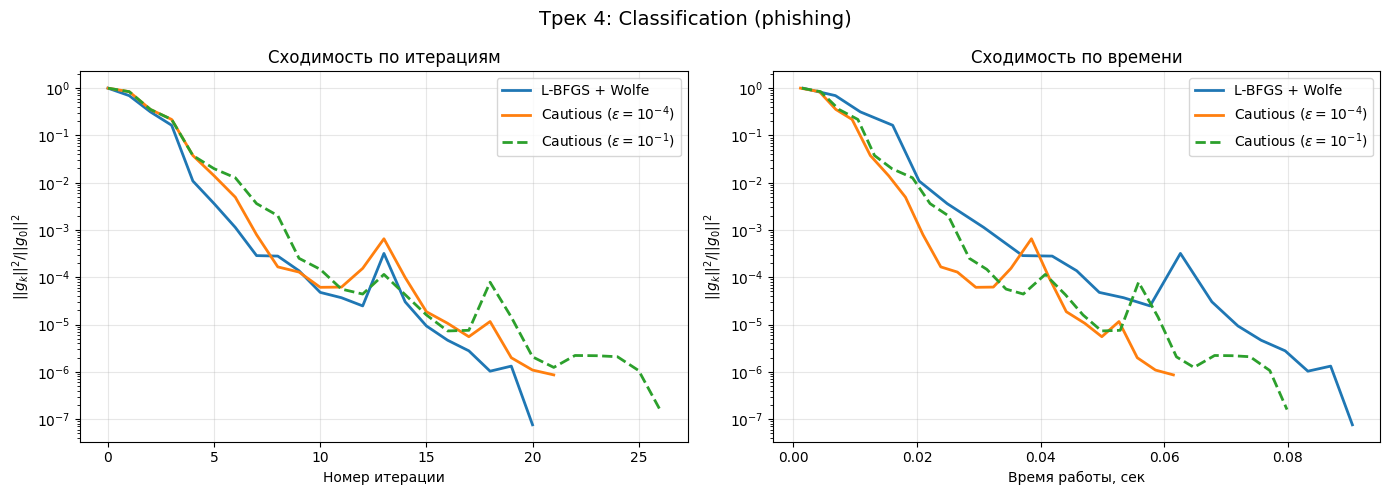


=== Запуск для задачи: regression (датасет: cadata) ===

--- СТАТУСЫ СХОДИМОСТИ ---
Wolfe:                   computational_error
Cautious (eps=1e-4):     iterations_exceeded
Cautious (eps=1e-1):     iterations_exceeded

--- ОТБРОШЕННЫЕ ПАРЫ (SK, YK) ---
Cautious (eps=1e-4): отброшено 199, принято 1
Cautious (eps=1e-1): отброшено 199, принято 1

--- ВЫЗОВЫ ОРАКУЛА В СРЕДНЕМ НА ИТЕРАЦИЮ ---
Wolfe:               16.00 вызовов (Всего: 14 f, 2 g)
Cautious (eps=1e-4): 5.20 вызовов (Всего: 638 f, 401 g)
Cautious (eps=1e-1): 5.20 вызовов (Всего: 638 f, 401 g)

--- ВРЕМЯ РАБОТЫ ---
Wolfe:               0.0012 сек
Cautious (eps=1e-4): 0.5045 сек
Cautious (eps=1e-1): 0.5270 сек
ВНИМАНИЕ: На датасете cadata наблюдается деградация метода из-за жесткости условия cautious. Это будет отмечено в отчете как стресс-кейс.


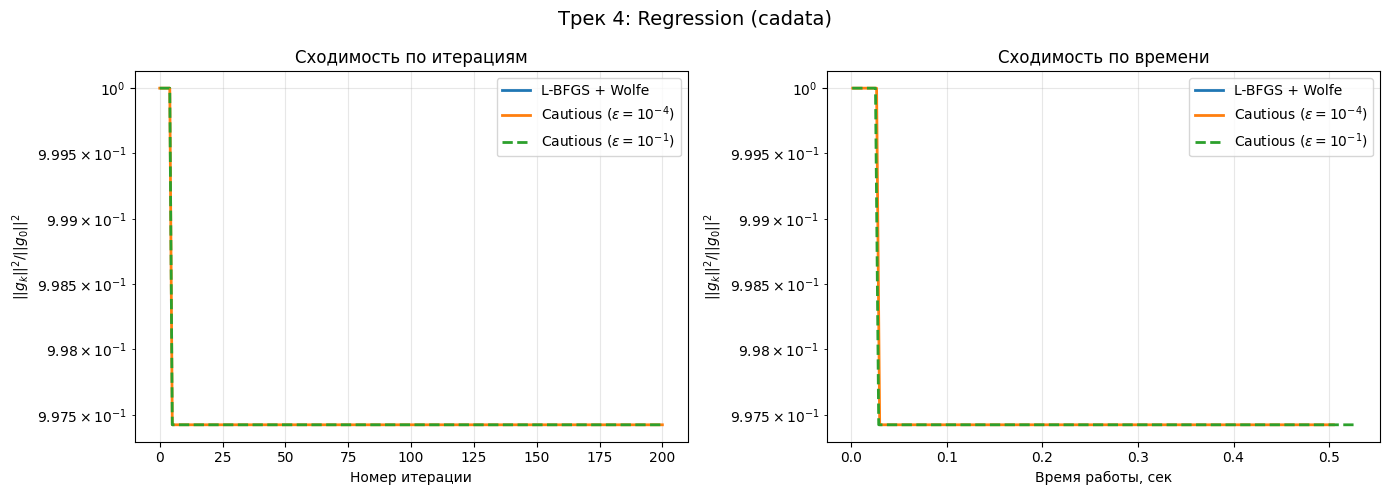

In [11]:
tasks = {
    "classification": "phishing",
    "regression": "cadata"
}

rng = np.random.default_rng(42)

for task, dataset_name in tasks.items():
    print(f"\n{'='*50}")
    print(f"=== Запуск для задачи: {task} (датасет: {dataset_name}) ===")
    print(f"{'='*50}")

    path = DATASETS[task][0]
    X, y, base_oracle = get_dataset_oracle(path, task)
    x0_random = rng.normal(loc=0.0, scale=np.sqrt(10.0), size=X.shape[1])

    oracle_wolfe = CountingOracle(base_oracle)
    oracle_cautious_def = CountingOracle(base_oracle)
    oracle_cautious_strict = CountingOracle(base_oracle)

    # 1. Классический L-BFGS + Wolfe
    _, msg_w, hist_w = lbfgs(
        oracle_wolfe, x0_random,
        tolerance=1e-6, max_iter=200, memory_size=10,
        line_search_options={"method": "Wolfe", "fallback_to_armijo": False},
        trace=True
    )

    # 2. Cautious L-BFGS + Armijo (eps = 1e-4, как в теории)
    _, msg_c_def, hist_c_def = cautious_lbfgs(
        oracle_cautious_def, x0_random,
        tolerance=1e-6, max_iter=200, memory_size=10,
        line_search_options={"method": "Armijo", "alpha_0": 1.0, "c1": 1e-4},
        cautious_eps=1e-4, cautious_alpha=1.0, trace=True
    )

    # 3. Cautious L-BFGS + Armijo (eps = 1e-1, искусственное ужесточение)
    _, msg_c_str, hist_c_str = cautious_lbfgs(
        oracle_cautious_strict, x0_random,
        tolerance=1e-6, max_iter=200, memory_size=10,
        line_search_options={"method": "Armijo", "alpha_0": 1.0, "c1": 1e-4},
        cautious_eps=1e-1, cautious_alpha=1.0, trace=True
    )

    print("\n--- СТАТУСЫ СХОДИМОСТИ ---")
    print(f"Wolfe:                   {msg_w}")
    print(f"Cautious (eps=1e-4):     {msg_c_def}")
    print(f"Cautious (eps=1e-1):     {msg_c_str}")

    print("\n--- ОТБРОШЕННЫЕ ПАРЫ (SK, YK) ---")
    print(f"Cautious (eps=1e-4): отброшено {hist_c_def['skipped_updates'][-1]}, принято {hist_c_def['accepted_updates'][-1]}")
    print(f"Cautious (eps=1e-1): отброшено {hist_c_str['skipped_updates'][-1]}, принято {hist_c_str['accepted_updates'][-1]}")

    print("\n--- ВЫЗОВЫ ОРАКУЛА В СРЕДНЕМ НА ИТЕРАЦИЮ ---")
    def calc_avg(hist, oracle):
        iters = max(len(hist['time']) - 1, 1)
        return (oracle.func_calls + oracle.grad_calls) / iters, oracle.func_calls, oracle.grad_calls

    avg_w, f_w, g_w = calc_avg(hist_w, oracle_wolfe)
    avg_c_def, f_cd, g_cd = calc_avg(hist_c_def, oracle_cautious_def)
    avg_c_str, f_cs, g_cs = calc_avg(hist_c_str, oracle_cautious_strict)

    print(f"Wolfe:               {avg_w:.2f} вызовов (Всего: {f_w} f, {g_w} g)")
    print(f"Cautious (eps=1e-4): {avg_c_def:.2f} вызовов (Всего: {f_cd} f, {g_cd} g)")
    print(f"Cautious (eps=1e-1): {avg_c_str:.2f} вызовов (Всего: {f_cs} f, {g_cs} g)")

    print("\n--- ВРЕМЯ РАБОТЫ ---")
    print(f"Wolfe:               {hist_w['time'][-1]:.4f} сек")
    print(f"Cautious (eps=1e-4): {hist_c_def['time'][-1]:.4f} сек")
    print(f"Cautious (eps=1e-1): {hist_c_str['time'][-1]:.4f} сек")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(np.arange(len(hist_w["grad_norm"])), relative_grad_sq(hist_w), linewidth=2, label="L-BFGS + Wolfe")
    axes[0].plot(np.arange(len(hist_c_def["grad_norm"])), relative_grad_sq(hist_c_def), linewidth=2, label=r"Cautious ($\epsilon=10^{-4}$)")
    axes[0].plot(np.arange(len(hist_c_str["grad_norm"])), relative_grad_sq(hist_c_str), linewidth=2, linestyle='--', label=r"Cautious ($\epsilon=10^{-1}$)")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Номер итерации")
    axes[0].set_ylabel(r"$||g_k||^2 / ||g_0||^2$")
    axes[0].set_title("Сходимость по итерациям")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist_w["time"], relative_grad_sq(hist_w), linewidth=2, label="L-BFGS + Wolfe")
    axes[1].plot(hist_c_def["time"], relative_grad_sq(hist_c_def), linewidth=2, label=r"Cautious ($\epsilon=10^{-4}$)")
    axes[1].plot(hist_c_str["time"], relative_grad_sq(hist_c_str), linewidth=2, linestyle='--', label=r"Cautious ($\epsilon=10^{-1}$)")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Время работы, сек")
    axes[1].set_ylabel(r"$||g_k||^2 / ||g_0||^2$")
    axes[1].set_title("Сходимость по времени")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Трек 4: {task.capitalize()} ({dataset_name})", fontsize=14)
    plt.tight_layout()
    fig.savefig(FIGURES / f"track4_{dataset_name}.png", bbox_inches="tight")

    if dataset_name == "cadata":
        skipped = int(hist_c_str["skipped_updates"][-1]) if hist_c_str.get("skipped_updates") else 0
        accepted = int(hist_c_str["accepted_updates"][-1]) if hist_c_str.get("accepted_updates") else 0
        total_pairs = skipped + accepted
        skipped_ratio = (skipped / total_pairs) if total_pairs > 0 else 0.0
        is_bad_status = ("computational_error" in str(msg_c_str).lower()) or (str(msg_c_str).lower() != "success")
        exceeded_iters = (len(hist_c_str.get("func", [])) - 1) >= 200
        if is_bad_status or (exceeded_iters and skipped_ratio >= 0.9):
            print("ВНИМАНИЕ: На датасете cadata наблюдается деградация метода из-за жесткости условия cautious. Это будет отмечено в отчете как стресс-кейс.")

    plt.show()